In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

import json

# Load

In [3]:
# Hyperparameters
gamma = 0.99

In [15]:
def calc_cost(dir, gamma):
    with open(dir, 'r') as f:
        sim = json.load(f)

    cost_list = []
    for i in range(len(sim)): # Sim
        for j in range(len(sim[i]['hist_cost'])): # Site
            total_cost = 0
            total_time = 0
            for k in range(len(sim[i]['hist_cost'][j])):
                cost = sim[i]['hist_cost'][j][k][1]
                time = sim[i]['hist_cost'][j][k][0]
                # print(cost, cost * (gamma ** total_time), total_time)
                total_cost += cost * (gamma ** total_time)
                total_time += time

            total_cost /= ((1-gamma**(total_time+1))/(1-gamma))
            cost_list.append(total_cost)

    return cost_list

In [5]:
with open('simulation_results/2024-06-20-05-18-05_result_collaborative.json', 'r') as f:
    sim = json.load(f)
len(sim)

10

In [12]:
sim[0]['hist_cost'][0][0]

[12, -5.044319243585807]

In [16]:
# fed_cost_noise_0001 = calc_cost('simulation_results/2024-05-26-18-26-33_federated_noise.json')
# fed_cost_noise_01 = calc_cost('simulation_results/2024-05-26-19-55-53_federated_noise.json')
# fed_cost_noise_1 = calc_cost('simulation_results/2024-05-26-21-28-58_federated_noise.json')
# fed_cost_noise_10 = calc_cost('simulation_results/2024-05-26-21-56-15_federated_noise.json')
fed_cost = calc_cost('simulation_results/2024-06-20-05-18-05_result_collaborative.json', 0.99)
# ovi_cost = calc_cost('simulation_results/2023-12-27-12-38-03_OVI.json')
# fed_async_cost = calc_cost('simulation_results/2023-12-27-18-41-15_async_federated.json')
# iso_async_cost = calc_cost('simulation_results/2023-12-27-23-51-05_async_isolated.json')
# ovi_async_cost = calc_cost('simulation_results/2023-12-28-07-49-27_async_OVI.json')

sim_accu = [fed_cost]

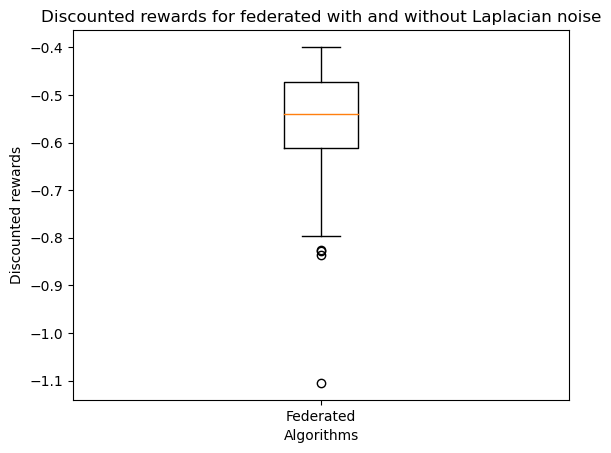

In [17]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.svg")
plt.title("Discounted rewards for federated with and without Laplacian noise")
plt.show()

In [21]:
np.std(np.array(sim_accu).T, axis=0)

array([0.14545112, 0.16423929, 0.14400126, 0.148049  , 0.14685389])

In [22]:
np.mean(np.array(sim_accu).T, axis=0)

array([-0.67889083, -0.66369936, -0.67637253, -0.67298381, -0.6573389 ])

# Small $M$

In [7]:
fed_cost = calc_cost('simulation_results/2024-02-05-10-08-17_federated.json')
iso_cost = calc_cost('simulation_results/2024-02-05-10-01-25_isolated.json')
sim_accu = [fed_cost, iso_cost]

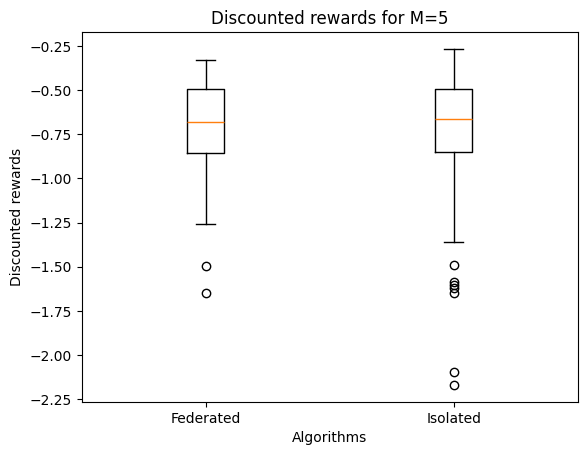

In [8]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.svg")
plt.title("Discounted rewards for M=5")
plt.show()

In [10]:
np.std(np.array(sim_accu).T, axis=0) / np.sqrt(len(sim_accu[0]))

array([0.02527097, 0.03542079])

In [11]:
np.mean(np.array(sim_accu).T, axis=0)

array([-0.7015415 , -0.73552836])

# Small $M$, small $\sigma_2$

In [15]:
fed_cost = calc_cost('simulation_results/2024-02-05-10-29-20_federated.json')
iso_cost = calc_cost('simulation_results/2024-02-05-10-34-32_isolated.json')
sim_accu = [fed_cost, iso_cost]

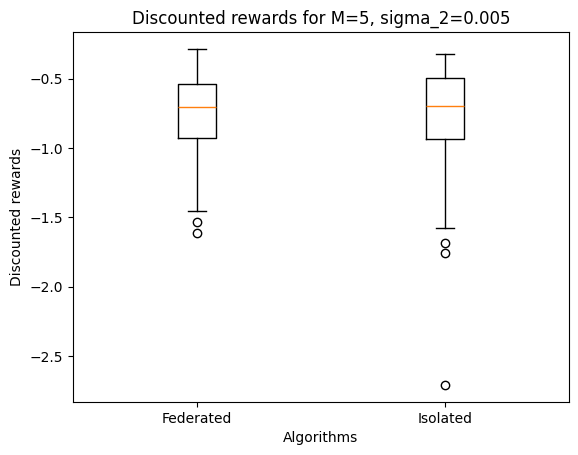

In [16]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.svg")
plt.title("Discounted rewards for M=5, sigma_2=0.005")
plt.show()

In [17]:
np.std(np.array(sim_accu).T, axis=0)

array([0.30992245, 0.37157709])

In [18]:
np.mean(np.array(sim_accu).T, axis=0)

array([-0.75058607, -0.77128338])

## More simulations

In [35]:
fed_cost = calc_cost('simulation_results/2024-02-05-13-01-36_federated.json')
iso_cost = calc_cost('simulation_results/2024-02-05-13-12-44_isolated.json')
sim_accu = [fed_cost, iso_cost]

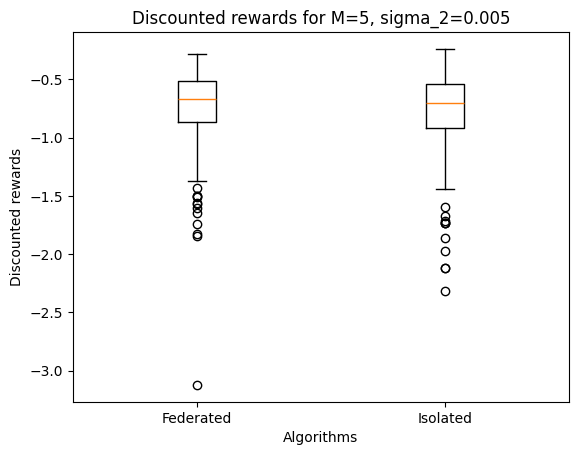

In [36]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.svg")
plt.title("Discounted rewards for M=5, sigma_2=0.005")
plt.show()

In [37]:
np.std(np.array(sim_accu).T, axis=0)

array([0.32637571, 0.3308626 ])

In [38]:
np.mean(np.array(sim_accu).T, axis=0)

array([-0.73095733, -0.77184787])

# Small $M$, small $\sigma_2$, $N=50$

In [26]:
fed_cost = calc_cost('simulation_results/2024-02-05-11-00-43_federated.json')
iso_cost = calc_cost('simulation_results/2024-02-05-11-33-32_isolated.json')
sim_accu = [fed_cost, iso_cost]

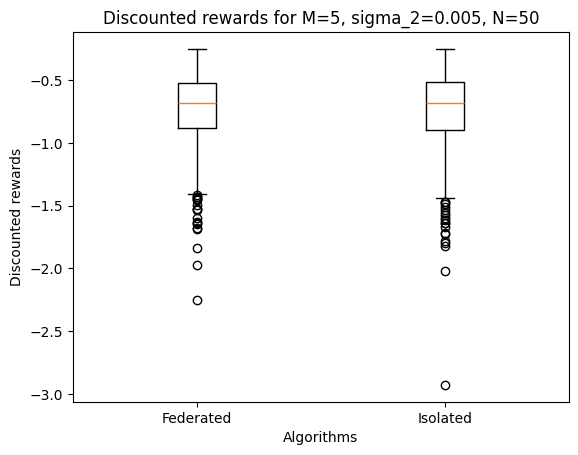

In [27]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.svg")
plt.title("Discounted rewards for M=5, sigma_2=0.005, N=50")
plt.show()

In [28]:
np.std(np.array(sim_accu).T, axis=0)

array([0.3004694 , 0.32337063])

In [29]:
np.mean(np.array(sim_accu).T, axis=0)

array([-0.74041757, -0.74481593])

# Small $M$, small $\sigma_2$, $N=25$

In [30]:
fed_cost = calc_cost('simulation_results/2024-02-05-11-48-48_federated.json')
iso_cost = calc_cost('simulation_results/2024-02-05-12-42-40_isolated.json')
sim_accu = [fed_cost, iso_cost]

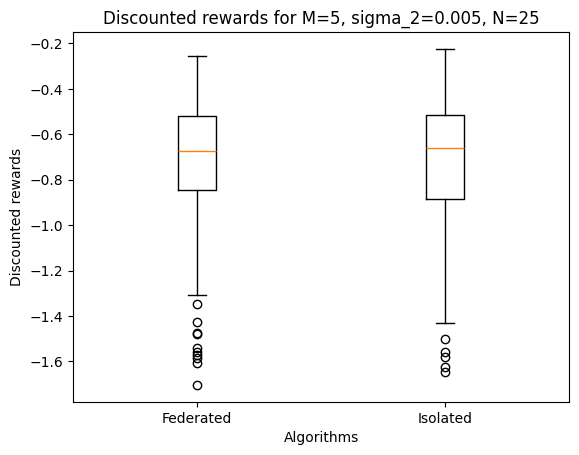

In [32]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.svg")
plt.title("Discounted rewards for M=5, sigma_2=0.005, N=25")
plt.show()

In [33]:
np.std(np.array(sim_accu).T, axis=0)

array([0.28213175, 0.27723257])

In [34]:
np.mean(np.array(sim_accu).T, axis=0)

array([-0.72168356, -0.71591889])

# Small $M$, small $\sigma_2$, large $\sigma_1 = 0.5$

In [39]:
fed_cost = calc_cost('simulation_results/2024-02-05-18-57-16_federated.json')
iso_cost = calc_cost('simulation_results/2024-02-05-19-04-47_isolated.json')
sim_accu = [fed_cost, iso_cost]

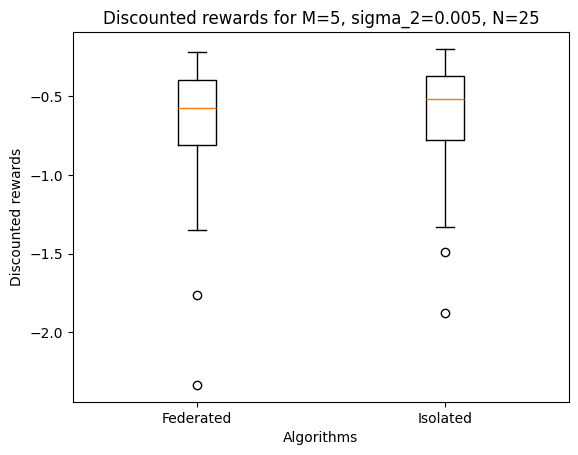

In [40]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.svg")
plt.title("Discounted rewards for M=5, sigma_2=0.005, N=25")
plt.show()

In [41]:
np.std(np.array(sim_accu).T, axis=0)

array([0.34174581, 0.30214469])

In [42]:
np.mean(np.array(sim_accu).T, axis=0)

array([-0.64489   , -0.60673645])

## Large N, large sigma1

In [8]:
fed_dir = 'simulation_results/2024-01-05-13-22-19_federated.json'
iso_dir = 'simulation_results/2024-01-05-14-53-38_isolated.json'

with open(fed_dir, 'r') as f:
    sim_fed = json.load(f)

with open(iso_dir, 'r') as f:
    sim_iso = json.load(f)

In [9]:
sim_fed_mean = np.zeros((10, 30, 20))
sim_iso_mean = np.zeros((10, 30, 20))

for i in range(len(sim_fed)):
    for k in range(30):
        sim_fed_mean[i, k, :] = np.array(sim_fed[i][1][k])
        sim_iso_mean[i, k, :] = np.array(sim_iso[i][1][k])

sim_fed_mean = np.mean(sim_fed_mean, axis=-1).flatten()
sim_iso_mean = np.mean(sim_iso_mean, axis=-1).flatten()

sim_mean = np.zeros((300, 2))
sim_mean[:, 0] = sim_fed_mean
sim_mean[:, 1] = sim_iso_mean
# sim_mean[:, 4] = sim_iso_async_mean
# sim_mean[:, 5] = sim_ovi_async_mean

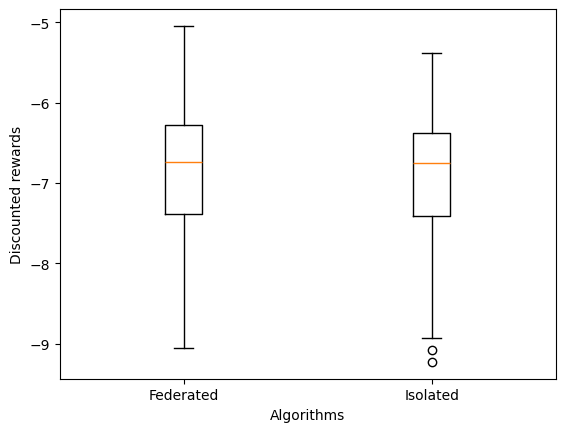

In [10]:
fig, ax = plt.subplots()
ax.boxplot(sim_mean, labels=['Federated', 'Isolated'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards.png")
plt.show()

In [11]:
np.std(sim_mean, axis=0)

array([0.80215365, 0.78041072])

In [12]:
np.mean(sim_mean, axis=0)

array([-6.80408836, -6.81644738])

## Large N (50, 100)

In [6]:
fed50_cost = calc_cost('simulation_results/2024-01-07-10-32-33_federated.json')
iso50_cost = calc_cost('simulation_results/2024-01-07-12-09-33_isolated.json')
fed100_cost = calc_cost('simulation_results/2024-01-07-18-27-52_federated.json')
iso100_cost = calc_cost('simulation_results/2024-01-07-22-28-15_isolated.json')

sim_accu = [fed50_cost, iso50_cost, fed100_cost, iso100_cost]

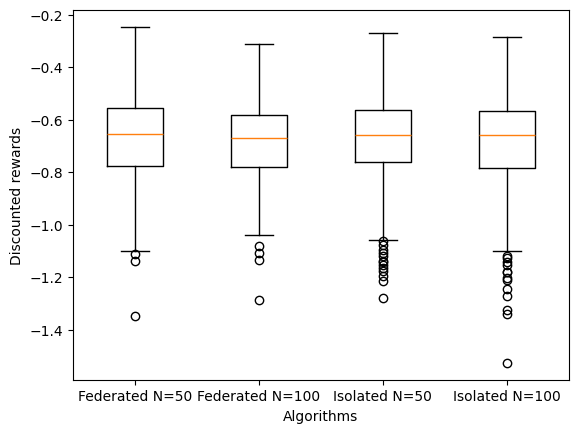

In [12]:
fig, ax = plt.subplots()
ax.boxplot(sim_accu, labels=['Federated N=50', 'Federated N=100', 'Isolated N=50', 'Isolated N=100'])
ax.set_xlabel("Algorithms")
ax.set_ylabel("Discounted rewards")

plt.savefig("rewards_N.svg")
plt.show()

In [8]:
np.mean(fed50_cost), np.std(fed50_cost)

(-0.670349977707769, 0.15983225285324484)

In [9]:
np.mean(fed100_cost), np.std(fed100_cost)

(-0.6733293442157742, 0.15494273495687674)

In [10]:
np.mean(iso50_cost), np.std(iso50_cost)

(-0.6831169861063227, 0.1415731777039056)

In [11]:
np.mean(iso100_cost), np.std(iso100_cost)

(-0.6830732608371946, 0.16862167288568314)